# Optional Lab: 特征缩放和学习率（多变量）

## 目标
在本实验中，你将：
- 利用上一个实验中开发的多变量例程。
- 在具有多个特征的数据集上运行梯度下降。
- 探索“学习率 alpha”对梯度下降的影响。
- 通过使用 z-score归一化进行“特征缩放”来提高梯度下降的性能。

## 工具
你将使用上一个实验中开发的函数以及 matplotlib 和 NumPy。

In [1]:
import numpy as np
np.set_printoptions(precision=2)
import matplotlib.pyplot as plt
dlblue = '#0096ff'; dlorange = '#FF9300'; dldarkred='#C00000'; dlmagenta='#FF40FF'; dlpurple='#7030A0'; 
plt.style.use('./deeplearning.mplstyle')
from lab_utils_multi import  load_house_data, compute_cost, run_gradient_descent 
from lab_utils_multi import  norm_plot, plt_contour_multi, plt_equal_scale, plot_cost_i_w

## 符号说明
|通用符号|描述|Python（如果适用）|
|:------------|:------------------------------------------------------------|---|
|$a$|标量，非粗体||
|$\mathbf{a}$|向量，粗体||
|$\mathbf{A}$|矩阵，粗体大写||
|**回归**|         |    |     |
|$\mathbf{X}$|训练样本矩阵|`X_train`|
|$\mathbf{y}$|训练样本目标|`y_train`|
|$\mathbf{x}^{(i)}$，$y^{(i)}$|第$i$个训练样本|`X[i]`，`y[i]`|
|$m$|训练样本数量|`m`|
|$n$|每个样本的特征数量|`n`|
|$\mathbf{w}$|参数：权重|`w`|
|$b$|参数：偏差|`b`|
|$f_{\mathbf{w},b}(\mathbf{x}^{(i)})$|在由$\mathbf{w}$，$b$参数化的$\mathbf{x}^{(i)}$处的模型评估结果：$f_{\mathbf{w},b}(\mathbf{x}^{(i)})=\mathbf{w}\cdot\mathbf{x}^{(i)}+b$|`f_wb`|
|$\frac{\partial J(\mathbf{w},b)}{\partial w_j}$|代价函数关于参数$w_j$的梯度或偏导数|`dj_dw[j]`|
|$\frac{\partial J(\mathbf{w},b)}{\partial b}$|代价函数关于参数$b$的梯度或偏导数|`dj_db`|

# 问题陈述
与之前的实验一样，你将进行房价预测。训练数据集包含许多示例，具有四个特征（面积、卧室数量、楼层数和房屋年龄），如下表所示。请注意，在本次实验中，面积特征以平方英尺为单位，而之前的实验使用的是 1000 平方英尺。这个数据集比之前的实验更大。我们希望使用这些值构建一个线性回归模型，以便我们可以预测其他房屋的价格——例如，一个面积为 1200 平方英尺、有 3 间卧室、1 层楼、40 年房龄的房屋。
## 数据集：
|面积（平方英尺）|卧室数量|楼层数量|房屋年龄|价格（千美元）|
|----|----|----|----|----|
|952|2|1|65|271.5|
|1244|3|2|64|232|
|1947|3|2|17|509.8|
|...|...|...|...|...|


In [2]:
# load the dataset
X_train, y_train = load_house_data()
X_features = ['size(sqft)','bedrooms','floors','age']

让我们通过绘制每个特征与价格的关系图来查看数据集及其特征。

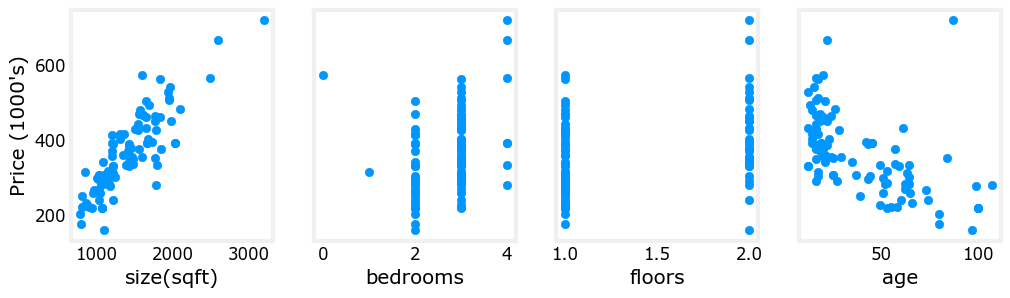

In [3]:
fig,ax=plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

绘制每个特征与目标（价格）的关系图，可以提供哪些特征对价格有最强影响的一些迹象。如上文所述，面积增大价格也会上涨。卧室数量和楼层似乎对价格没有很强的影响。较新的房屋比较旧的房屋价格更高。

<a name="toc_15456_5"></a>
## 多元变量的梯度下降
以下是你在上一个关于多元变量梯度下降的实验中得出的方程：

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j := w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j = 0..n-1}\newline
&b\ \ := b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

其中，n 是特征的数量，参数$w_j$和$b$同时更新，并且其中：

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{2}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{3}
\end{align}
$$
* m 是数据集中训练样本的数量。

    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$是模型的预测值，而$y^{(i)}$是目标值。


## 学习率
<figure>
    <img src="../work/images/C1_W2_Lab06_learningrate.PNG" style="width:1200px;" >
</figure>
讲座讨论了一些与设置学习率α相关的问题。学习率控制着参数更新的大小。请参见上面的公式（1）。它由所有参数共享。

让我们运行梯度下降，并在我们的数据集上尝试一些α的设置。

### $\alpha$ = 9.9e-7

In [4]:
#set alpha to 9.9e-7
_, _, hist = run_gradient_descent(X_train, y_train, 10, alpha = 9.9e-7)

Iteration Cost          w0       w1       w2       w3       b       djdw0    djdw1    djdw2    djdw3    djdb  
---------------------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
        0 9.55884e+04  5.5e-01  1.0e-03  5.1e-04  1.2e-02  3.6e-04 -5.5e+05 -1.0e+03 -5.2e+02 -1.2e+04 -3.6e+02
        1 1.28213e+05 -8.8e-02 -1.7e-04 -1.0e-04 -3.4e-03 -4.8e-05  6.4e+05  1.2e+03  6.2e+02  1.6e+04  4.1e+02
        2 1.72159e+05  6.5e-01  1.2e-03  5.9e-04  1.3e-02  4.3e-04 -7.4e+05 -1.4e+03 -7.0e+02 -1.7e+04 -4.9e+02
        3 2.31358e+05 -2.1e-01 -4.0e-04 -2.3e-04 -7.5e-03 -1.2e-04  8.6e+05  1.6e+03  8.3e+02  2.1e+04  5.6e+02
        4 3.11100e+05  7.9e-01  1.4e-03  7.1e-04  1.5e-02  5.3e-04 -1.0e+06 -1.8e+03 -9.5e+02 -2.3e+04 -6.6e+02
        5 4.18517e+05 -3.7e-01 -7.1e-04 -4.0e-04 -1.3e-02 -2.1e-04  1.2e+06  2.1e+03  1.1e+03  2.8e+04  7.5e+02
        6 5.63212e+05  9.7e-01  1.7e-03  8.7e-04  1.8e-02  6.6e-04 -1.3e+06 -2.5e+03 -1.3e+03 -3.1e+04 -

看起来学习率太高了。解决方案不收敛。成本在*增加*而不是减少。让我们绘制结果：

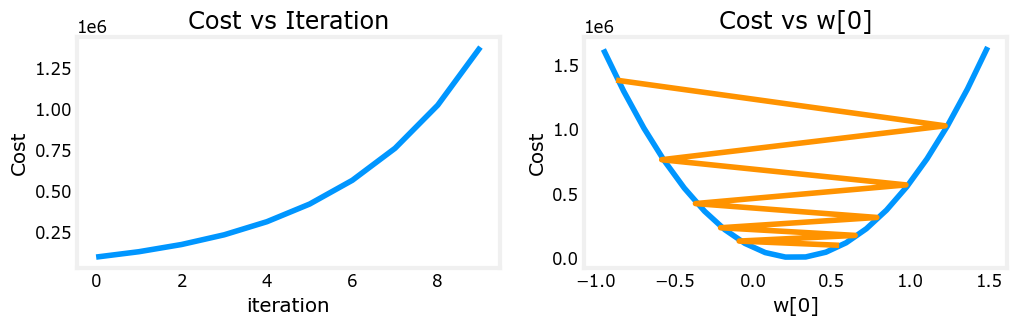

In [5]:
plot_cost_i_w(X_train, y_train, hist)

右侧的图显示了其中一个参数的值，$w_0$。在每次迭代中，它都超过了最优值，结果，成本最终*增加*而不是接近最小值。请注意，这并不是一个完全准确的图像，因为每次迭代中有 4 个参数被修改，而不仅仅是一个。此图仅显示$w_0$，其他参数固定为良性值。在这个图和后面的图中，你可能会注意到蓝色和橙色线略有偏离。α = 9e-7。让我们尝试一个更小的值，看看会发生什么。


### $\alpha$ = 9e-7
让我们尝试一个稍小的值，看看会发生什么。

In [6]:
#set alpha to 9e-7
_,_,hist = run_gradient_descent(X_train, y_train, 10, alpha = 9e-7)

Iteration Cost          w0       w1       w2       w3       b       djdw0    djdw1    djdw2    djdw3    djdb  
---------------------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
        0 6.64616e+04  5.0e-01  9.1e-04  4.7e-04  1.1e-02  3.3e-04 -5.5e+05 -1.0e+03 -5.2e+02 -1.2e+04 -3.6e+02
        1 6.18990e+04  1.8e-02  2.1e-05  2.0e-06 -7.9e-04  1.9e-05  5.3e+05  9.8e+02  5.2e+02  1.3e+04  3.4e+02
        2 5.76572e+04  4.8e-01  8.6e-04  4.4e-04  9.5e-03  3.2e-04 -5.1e+05 -9.3e+02 -4.8e+02 -1.1e+04 -3.4e+02
        3 5.37137e+04  3.4e-02  3.9e-05  2.8e-06 -1.6e-03  3.8e-05  4.9e+05  9.1e+02  4.8e+02  1.2e+04  3.2e+02
        4 5.00474e+04  4.6e-01  8.2e-04  4.1e-04  8.0e-03  3.2e-04 -4.8e+05 -8.7e+02 -4.5e+02 -1.1e+04 -3.1e+02
        5 4.66388e+04  5.0e-02  5.6e-05  2.5e-06 -2.4e-03  5.6e-05  4.6e+05  8.5e+02  4.5e+02  1.2e+04  2.9e+02
        6 4.34700e+04  4.5e-01  7.8e-04  3.8e-04  6.4e-03  3.2e-04 -4.4e+05 -8.1e+02 -4.2e+02 -9.8e+03 -

在整个运行过程中成本在下降，这表明α不是太大。

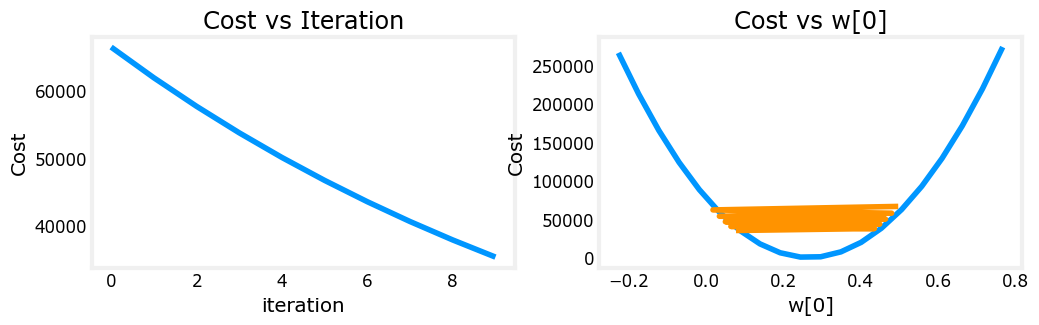

In [7]:
plot_cost_i_w(X_train, y_train, hist)

在左侧，你可以看到成本如预期那样在下降。在右侧，你可以看到$w_0$仍在最小值附近振荡，但每次迭代都在减小而不是增加。请注意，随着$w[0]$跳过最优值，`dj_dw[0]`在每次迭代中都会改变符号。这个 alpha 值将会收敛。你可以改变迭代次数以观察它的行为。

### $\alpha$ = 1e-7
Let's try a bit smaller value for $\alpha$ and see what happens.

In [8]:
#set alpha to 1e-7
_,_,hist = run_gradient_descent(X_train, y_train, 10, alpha = 1e-7)

Iteration Cost          w0       w1       w2       w3       b       djdw0    djdw1    djdw2    djdw3    djdb  
---------------------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
        0 4.42313e+04  5.5e-02  1.0e-04  5.2e-05  1.2e-03  3.6e-05 -5.5e+05 -1.0e+03 -5.2e+02 -1.2e+04 -3.6e+02
        1 2.76461e+04  9.8e-02  1.8e-04  9.2e-05  2.2e-03  6.5e-05 -4.3e+05 -7.9e+02 -4.0e+02 -9.5e+03 -2.8e+02
        2 1.75102e+04  1.3e-01  2.4e-04  1.2e-04  2.9e-03  8.7e-05 -3.4e+05 -6.1e+02 -3.1e+02 -7.3e+03 -2.2e+02
        3 1.13157e+04  1.6e-01  2.9e-04  1.5e-04  3.5e-03  1.0e-04 -2.6e+05 -4.8e+02 -2.4e+02 -5.6e+03 -1.8e+02
        4 7.53002e+03  1.8e-01  3.3e-04  1.7e-04  3.9e-03  1.2e-04 -2.1e+05 -3.7e+02 -1.9e+02 -4.2e+03 -1.4e+02
        5 5.21639e+03  2.0e-01  3.5e-04  1.8e-04  4.2e-03  1.3e-04 -1.6e+05 -2.9e+02 -1.5e+02 -3.1e+03 -1.1e+02
        6 3.80242e+03  2.1e-01  3.8e-04  1.9e-04  4.5e-03  1.4e-04 -1.3e+05 -2.2e+02 -1.1e+02 -2.3e+03 -

在整个运行过程中成本在降低，这表明\(\alpha\)不是太大。

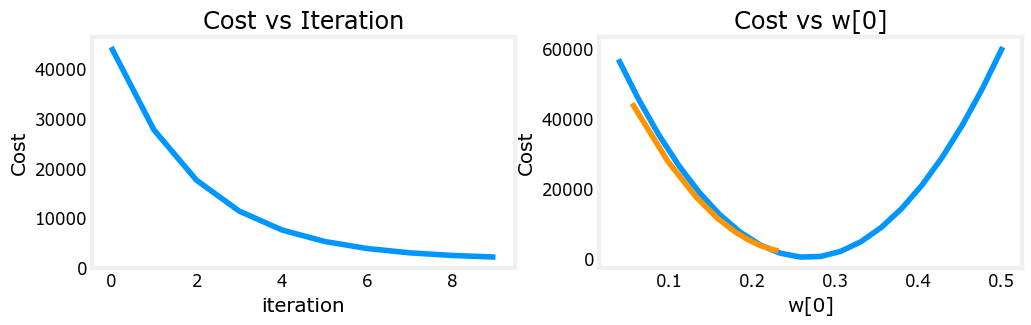

In [9]:
plot_cost_i_w(X_train,y_train,hist)

在左侧，你可以看到成本如预期那样在降低。在右侧，你可以看到 $w_0$ 在降低且没有穿过最小值。请注意，上面的 `dj_w0` 在整个运行过程中都是负的。这个解也会收敛，尽管不如前一个例子那么快。


## 特征缩放
<figure>
    <img src="../work/images/C1_W2_Lab06_featurescalingheader.PNG" style="width:1200px;" >
</figure>
讲座描述了重新缩放数据集的重要性，以便特征具有相似的范围。如果你对为什么会这样的细节感兴趣，请点击下面的“细节”标题。如果不感兴趣，下面的部分将介绍如何进行特征缩放的实现。

<details>
<summary>
    <font size='3', color='darkgreen'><b>细节</b></font>
</summary>

让我们再次看看当$\alpha$ = 9e-7 时的情况。这非常接近我们可以设置$\alpha$而不会发散的最大值。这是一个展示前几次迭代的短期运行：

<figure>
    <img src="../work/images/C1_W2_Lab06_ShortRun.PNG" style="width:1200px;" >
</figure>

上面，在成本降低的同时，很明显由于$w_0$的梯度大得多，所以它比其他参数进步得更快。
下面的图形展示了使用$\alpha$ = 9e-7 进行非常长时间运行的结果。这需要几个小时。

<figure>
    <img src="../work/images/C1_W2_Lab06_LongRun.PNG" style="width:1200px;" >
</figure>
    
上面，你可以看到成本在最初降低后缓慢下降。注意`w0`与`w0`、`w1`、`w2`以及`dj_dw0`与`dj_dw1 - 3`之间的差异。`w0`很快达到接近最终的值，并且`dj_dw0`迅速下降到一个小值，表明`w0`接近最终值。其他参数的下降速度要慢得多。

这是为什么呢？有什么我们可以改进的地方吗？如下所示：

<figure>
    <center> <img src="../work/images/C1_W2_Lab06_scale.PNG"   ></center>
</figure>   

上面的图展示了为什么$w$的更新是不均匀的。
- $\alpha$被所有参数更新（$w$和$b$）共享。
- 公共误差项乘以$w$的特征（不是$b$）。
- 特征的大小差异很大，使得一些特征的更新速度比其他特征快得多。在这种情况下，$w_0$乘以“面积（平方英尺）”，通常大于 1000，而$w_1$乘以“卧室数量”，通常为 2 - 4。
解决方案是特征缩放。


讲座讨论了三种不同的技术：
- 特征缩放，本质上是将每个特征除以用户选择的值，以得到在-1 和 1 之间的范围。
- 均值归一化：$x_i := \dfrac{x_i - \mu_i}{max - min}$。
- 标准差归一化，我们将在下面探讨。


### z 分数标准化
z 分数标准化后，所有特征的均值将为 0，标准差将为 1。
要实现 z 分数标准化，请按照此公式调整输入值：
$$x^{(i)}_j = \dfrac{x^{(i)}_j - \mu_j}{\sigma_j} \tag{4}$$
其中，$j$选择 X 矩阵中的一个特征或一列。$µ_j$是特征（j）的所有值的均值，$\sigma_j$是特征（j）的标准差。
$$
\begin{align}
\mu_j &= \frac{1}{m} \sum_{i=0}^{m-1} x^{(i)}_j \tag{5}\\
\sigma^2_j &= \frac{1}{m} \sum_{i=0}^{m-1} (x^{(i)}_j - \mu_j)^2  \tag{6}
\end{align}
$$
>**实现注意事项**：在对特征进行标准化时，重要的是存储用于标准化的值——用于计算的均值和标准差。从模型中学习参数后，我们通常希望预测我们以前从未见过的房屋价格。给定一个新的 x 值（客厅面积和卧室数量），我们必须首先使用均值和标准差对 x 进行标准化。



**实现**

In [10]:
def zscore_normalize_features(X):
    """
    computes  X, zcore normalized by column
    
    Args:
      X (ndarray): Shape (m,n) input data, m examples, n features
      
    Returns:
      X_norm (ndarray): Shape (m,n)  input normalized by column
      mu (ndarray):     Shape (n,)   mean of each feature
      sigma (ndarray):  Shape (n,)   standard deviation of each feature
    """
    # find the mean of each column/feature
    mu     = np.mean(X, axis=0)                 # mu will have shape (n,)
    # find the standard deviation of each column/feature
    sigma  = np.std(X, axis=0)                  # sigma will have shape (n,)
    # element-wise, subtract mu for that column from each example, divide by std for that column
    X_norm = (X - mu) / sigma      

    return (X_norm, mu, sigma)
 
#check our work
#from sklearn.preprocessing import scale
#scale(X_orig, axis=0, with_mean=True, with_std=True, copy=True)

让我们看看 Z-score 标准化所涉及的步骤。下面的图逐步展示了转换过程。

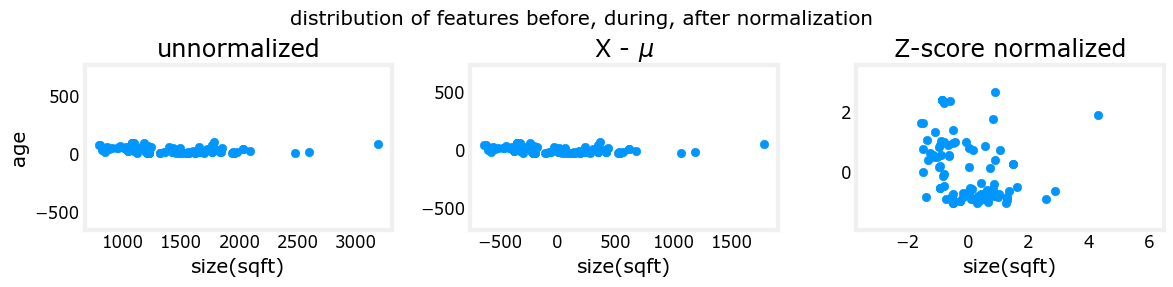

In [11]:
mu     = np.mean(X_train,axis=0)   
sigma  = np.std(X_train,axis=0) 
X_mean = (X_train - mu)
X_norm = (X_train - mu)/sigma      

fig,ax=plt.subplots(1, 3, figsize=(12, 3))
ax[0].scatter(X_train[:,0], X_train[:,3])
ax[0].set_xlabel(X_features[0]); ax[0].set_ylabel(X_features[3]);
ax[0].set_title("unnormalized")
ax[0].axis('equal')

ax[1].scatter(X_mean[:,0], X_mean[:,3])
ax[1].set_xlabel(X_features[0]); ax[0].set_ylabel(X_features[3]);
ax[1].set_title(r"X - $\mu$")
ax[1].axis('equal')

ax[2].scatter(X_norm[:,0], X_norm[:,3])
ax[2].set_xlabel(X_features[0]); ax[0].set_ylabel(X_features[3]);
ax[2].set_title(r"Z-score normalized")
ax[2].axis('equal')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("distribution of features before, during, after normalization")
plt.show()

上面的图展示了训练集的两个参数“年龄”和“平方英尺”之间的关系。*这些是用等比例绘制的*。
- 左图：未归一化：“房屋面积（平方英尺）”特征的值范围或方差比年龄的大得多。
- 中图：第一步找到从每个特征中减去均值或平均值。这使得特征围绕零中心。对于“年龄”特征很难看出差异，但“房屋面积（平方英尺）”显然在零附近。
- 右图：第二步除以方差。这使得两个特征都以零为中心且具有相似的比例。


让我们对数据进行归一化并将其与原始数据进行比较。

In [12]:
# normalize the original features
X_norm, X_mu, X_sigma = zscore_normalize_features(X_train)
print(f"X_mu = {X_mu}, \nX_sigma = {X_sigma}")
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X_train,axis=0)}")   
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X_norm,axis=0)}")

X_mu = [1.42e+03 2.72e+00 1.38e+00 3.84e+01], 
X_sigma = [411.62   0.65   0.49  25.78]
Peak to Peak range by column in Raw        X:[2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Peak to Peak range by column in Normalized X:[5.85 6.14 2.06 3.69]


通过归一化，每列的峰对峰值范围从数千倍减小到 2 - 3 倍。

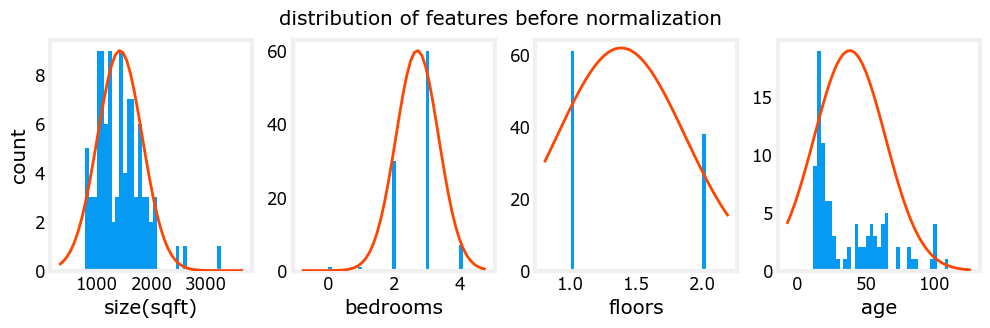

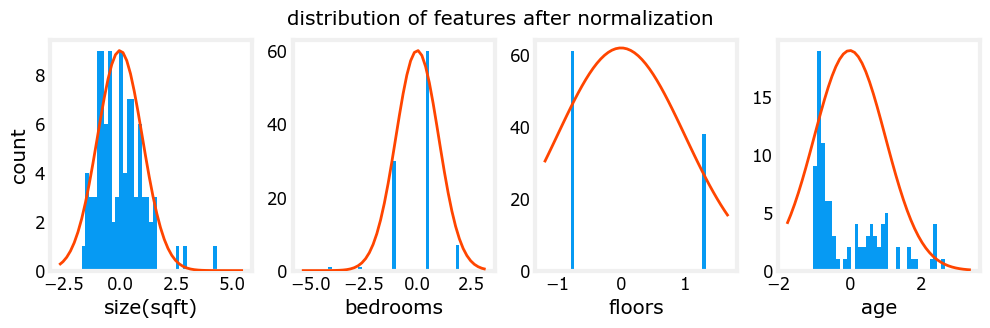

In [13]:
fig,ax=plt.subplots(1, 4, figsize=(12, 3))
for i in range(len(ax)):
    norm_plot(ax[i],X_train[:,i],)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("count");
fig.suptitle("distribution of features before normalization")
plt.show()
fig,ax=plt.subplots(1,4,figsize=(12,3))
for i in range(len(ax)):
    norm_plot(ax[i],X_norm[:,i],)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("count"); 
fig.suptitle(f"distribution of features after normalization")

plt.show()

请注意，上面归一化数据的范围以零为中心，大约在+/- 1 左右。最重要的是，每个特征的范围相似。

让我们用归一化的数据重新运行我们的梯度下降算法。注意**alpha 的值要大得多**。这将加快下降速度。

In [14]:
w_norm, b_norm, hist = run_gradient_descent(X_norm, y_train, 1000, 1.0e-1, )

Iteration Cost          w0       w1       w2       w3       b       djdw0    djdw1    djdw2    djdw3    djdb  
---------------------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
        0 5.76170e+04  8.9e+00  3.0e+00  3.3e+00 -6.0e+00  3.6e+01 -8.9e+01 -3.0e+01 -3.3e+01  6.0e+01 -3.6e+02
      100 2.21086e+02  1.1e+02 -2.0e+01 -3.1e+01 -3.8e+01  3.6e+02 -9.2e-01  4.5e-01  5.3e-01 -1.7e-01 -9.6e-03
      200 2.19209e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -3.0e-02  1.5e-02  1.7e-02 -6.0e-03 -2.6e-07
      300 2.19207e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -1.0e-03  5.1e-04  5.7e-04 -2.0e-04 -6.9e-12
      400 2.19207e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -3.4e-05  1.7e-05  1.9e-05 -6.6e-06 -2.7e-13
      500 2.19207e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -1.1e-06  5.6e-07  6.2e-07 -2.2e-07 -2.7e-13
      600 2.19207e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -3.7e-08  1.9e-08  2.1e-08 -7.3e-09 -

缩放后的特征能得到非常准确的结果，而且速度快得多！注意，在这个相当短的运行结束时，每个参数的梯度都非常小。对于具有归一化特征的回归问题，0.1 的学习率是一个很好的起点。

让我们绘制我们的预测值与目标值的对比图。请注意，预测是使用归一化特征进行的，而绘图是使用原始特征值显示的。

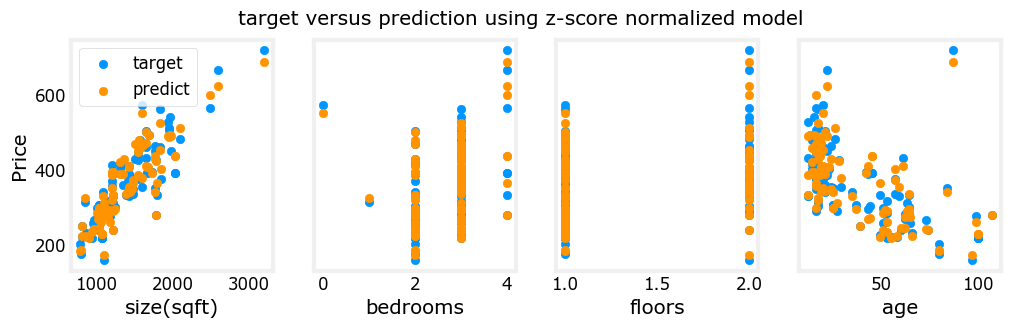

In [15]:
#predict target using normalized features
m = X_norm.shape[0]
yp = np.zeros(m)
for i in range(m):
    yp[i] = np.dot(X_norm[i], w_norm) + b_norm

    # plot predictions and targets versus original features    
fig,ax=plt.subplots(1,4,figsize=(12, 3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i],yp,color=dlorange, label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()

结果看起来不错。有几点需要注意：
- 有多个特征时，我们不能再用一个图来显示结果与特征的关系。
- 生成图时，使用了标准化特征。任何使用从标准化训练集学习到的参数进行的预测也必须进行标准化。

**预测**
生成我们的模型的目的是使用它来预测不在数据集中的房屋价格。让我们预测一个面积为 1200 平方英尺、有 3 间卧室、1 层楼、有 40 年历史的房屋的价格。请记住，在进行预测时，必须使用训练数据标准化时得出的均值和标准差对数据进行标准化。

In [16]:
# First, normalize out example.
x_house = np.array([1200, 3, 1, 40])
x_house_norm = (x_house - X_mu) / X_sigma
print(x_house_norm)
x_house_predict = np.dot(x_house_norm, w_norm) + b_norm
print(f" predicted price of a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old = ${x_house_predict*1000:0.0f}")

[-0.53  0.43 -0.79  0.06]
 predicted price of a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old = $318709


**成本等高线**  
<img align="left" src="../work/images/C1_W2_Lab06_contours.PNG"   style="width:240px;" >另一种看待特征缩放的方式是从成本等高线的角度。当特征尺度不匹配时，等高线图中成本与参数的关系图是不对称的。在下面的图中，参数的尺度是匹配的。左图是在特征归一化之前，w[0]（平方英尺）与 w[1]（卧室数量）的成本等高线图。该图非常不对称，完成等高线的曲线不可见。相比之下，当特征被归一化时，成本等高线更加对称。结果是，在梯度下降过程中对参数的更新可以使每个参数取得相同的进展。


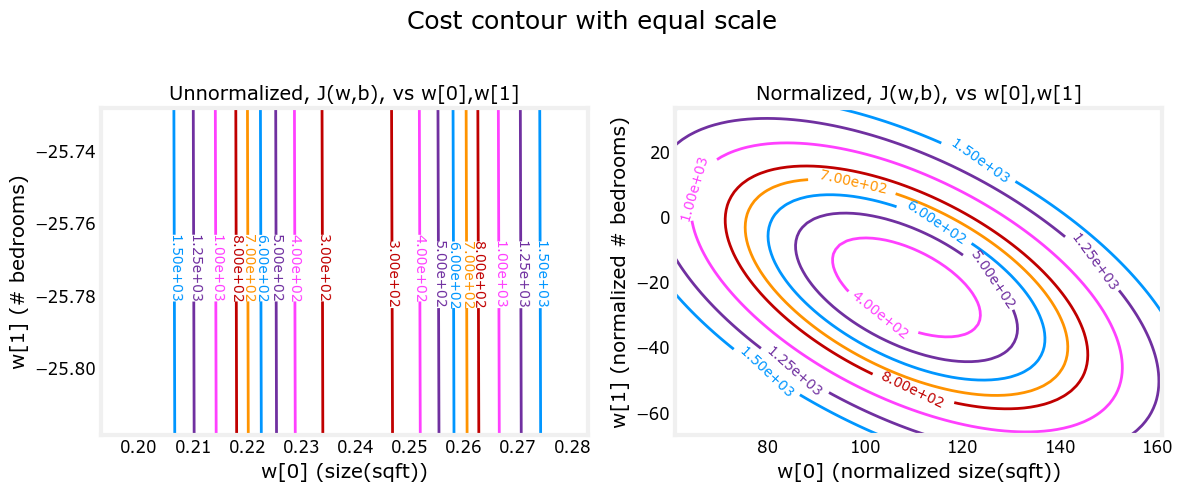

In [17]:
plt_equal_scale(X_train, X_norm, y_train)


## 恭喜！
在这个实验中，你：
- 利用了在之前的实验中开发的具有多个特征的线性回归例程。
- 探索了学习率$\alpha$对收敛的影响。
- 发现了使用 z-score 归一化进行特征缩放在加速收敛方面的价值。

## 鸣谢
房屋数据来源于迪恩·德·科克（Dean De Cock）为数据科学教育整理的[Ames Housing数据集](http://jse.amstat.org/v19n3/decock.pdf)。